# 04 · Otimizadores, arquiteturas e o que a rede enxerga

Três experimentos, todos avaliados na **validação** (o teste continua guardado):

1. **Otimizadores** — a mesma rede treinada com SGD, SGD + momentum, RMSprop, Adam, AdamW
   e Nadam (como no exercício do CIFAR-10).
2. **Arquiteturas** — profundidade, largura, Dropout e BatchNormalization.
3. **Superfície de decisão** — uma rede com apenas 2 entradas, para visualizar a fronteira
   não linear que as camadas ocultas aprendem (como no exercício dos vinhos).
4. **Busca automática de hiperparâmetros** — o Keras Tuner (Hyperband) explora dezenas de
   combinações de profundidade, largura, Dropout, BatchNorm e taxa de aprendizado.
5. **Agenda da taxa de aprendizado** — taxa fixa × redução no platô × decaimento cosseno.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.dados import preparar
from src.model import avaliacao, mlp_keras
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "04-otimizadores-arquiteturas"
particao = preparar()

## 1. Comparação de otimizadores

In [2]:
curvas, linhas = {}, []
for nome in mlp_keras.OTIMIZADORES:
    modelo = mlp_keras.construir_mlp(particao.n_entradas, otimizador=nome)
    inicio = time.perf_counter()
    hist = mlp_keras.treinar(
        modelo, particao.X_treino, particao.y_treino, particao.X_val, particao.y_val,
        epocas=60, paciencia=10,
    )
    duracao = time.perf_counter() - inicio
    curvas[nome] = hist.history["val_auc"]
    p_val = mlp_keras.prever(modelo, particao.X_val)
    linhas.append({
        "otimizador": nome,
        "taxa": mlp_keras.TAXA_PADRAO.get(nome, 1e-3),
        "auc_val": avaliacao.metricas(particao.y_val, p_val)["auc_roc"],
        "epocas": len(hist.history["loss"]),
        "segundos": duracao,
    })
    print(f"{nome:15s} AUC val {linhas[-1]['auc_val']:.4f}  ({linhas[-1]['epocas']} épocas, {duracao:.0f}s)")

otimizadores = pd.DataFrame(linhas).set_index("otimizador").sort_values("auc_val", ascending=False)
salvar_tabela(otimizadores.round(4), SECAO, "otimizadores")
otimizadores.round(4)

SGD             AUC val 0.8015  (60 épocas, 9s)


SGD + momentum  AUC val 0.8013  (34 épocas, 6s)


RMSprop         AUC val 0.8019  (27 épocas, 5s)


Adam            AUC val 0.8020  (31 épocas, 6s)


AdamW           AUC val 0.8019  (31 épocas, 6s)


Nadam           AUC val 0.8020  (31 épocas, 6s)


,taxa,auc_val,epocas,segundos
otimizador,,,,
Nadam,0.001,0.8020,31,6.1770
Adam,0.001,0.8020,31,5.7402
AdamW,0.001,0.8019,31,5.8941
RMSprop,0.001,0.8019,27,4.8663
SGD,0.050,0.8015,60,9.2091
SGD + momentum,0.010,0.8013,34,6.0034


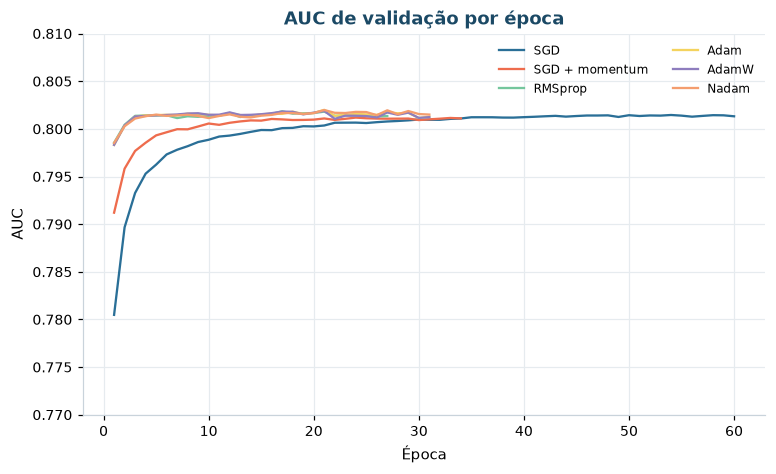

In [3]:
curvas = pd.DataFrame({k: pd.Series(v) for k, v in curvas.items()}).rename_axis("epoca")
fig, eixo = plt.subplots(figsize=(8, 4.5))
for (nome, serie), cor in zip(curvas.items(), config.PALETA):
    eixo.plot(serie.index + 1, serie, label=nome, color=cor)
eixo.set(title="AUC de validação por época", xlabel="Época", ylabel="AUC", ylim=(0.77, 0.81))
eixo.legend(fontsize=8, ncol=2)
salvar_figura(fig, SECAO, "otimizadores-curvas", curvas)
plt.show()

Os otimizadores adaptativos (Adam, AdamW, Nadam, RMSprop) chegam ao patamar final em
2 ou 3 épocas; o SGD puro sobe mais devagar e usa as 60 épocas inteiras. Como o problema é
pequeno e bem-comportado, todos terminam no mesmo teto (AUC ≈ 0,802 na validação): a escolha
pesa na **velocidade**, não na qualidade final.

## 2. Comparação de arquiteturas

In [4]:
arquiteturas = {
    "1 camada · 16": dict(ocultas=(16,), dropout=0.0),
    "2 camadas · 32-16": dict(ocultas=(32, 16), dropout=0.2),
    "3 camadas · 64-32-16": dict(ocultas=(64, 32, 16), dropout=0.2),
    "3 camadas · 64-32-16 sem dropout": dict(ocultas=(64, 32, 16), dropout=0.0),
    "3 camadas · 64-32-16 + BatchNorm": dict(ocultas=(64, 32, 16), dropout=0.2, batch_norm=True),
    "4 camadas · 128-64-32-16": dict(ocultas=(128, 64, 32, 16), dropout=0.3),
    "5 camadas · 256-128-64-32-16": dict(ocultas=(256, 128, 64, 32, 16), dropout=0.3),
}

linhas = []
for nome, kw in arquiteturas.items():
    modelo = mlp_keras.construir_mlp(particao.n_entradas, **kw)
    hist = mlp_keras.treinar(
        modelo, particao.X_treino, particao.y_treino, particao.X_val, particao.y_val,
        epocas=100, paciencia=12,
    )
    p_tr = mlp_keras.prever(modelo, particao.X_treino)
    p_val = mlp_keras.prever(modelo, particao.X_val)
    auc_tr = avaliacao.metricas(particao.y_treino, p_tr)["auc_roc"]
    auc_val = avaliacao.metricas(particao.y_val, p_val)["auc_roc"]
    linhas.append({"arquitetura": nome, "parametros": modelo.count_params(),
                   "auc_treino": auc_tr, "auc_val": auc_val, "distancia": auc_tr - auc_val,
                   "epocas": len(hist.history["loss"])})
    print(f"{nome:36s} AUC treino {auc_tr:.4f}  val {auc_val:.4f}")

tab_arq = pd.DataFrame(linhas).set_index("arquitetura")
salvar_tabela(tab_arq.round(4), SECAO, "arquiteturas")
tab_arq.round(4)

1 camada · 16                        AUC treino 0.8024  val 0.8007


2 camadas · 32-16                    AUC treino 0.8050  val 0.8024


3 camadas · 64-32-16                 AUC treino 0.8049  val 0.8020


3 camadas · 64-32-16 sem dropout     AUC treino 0.8020  val 0.8012


3 camadas · 64-32-16 + BatchNorm     AUC treino 0.8042  val 0.8023


4 camadas · 128-64-32-16             AUC treino 0.8058  val 0.8021


5 camadas · 256-128-64-32-16         AUC treino 0.8060  val 0.8019


,parametros,auc_treino,auc_val,distancia,epocas
arquitetura,,,,,
1 camada · 16,289,0.8024,0.8007,0.0017,61
2 camadas · 32-16,1089,0.8050,0.8024,0.0026,58
3 camadas · 64-32-16,3713,0.8049,0.8020,0.0029,33
3 camadas · 64-32-16 sem dropout,3713,0.8020,0.8012,0.0008,16
3 camadas · 64-32-16 + BatchNorm,4161,0.8042,0.8023,0.0020,33
4 camadas · 128-64-32-16,13057,0.8058,0.8021,0.0036,35
5 camadas · 256-128-64-32-16,48129,0.8060,0.8019,0.0041,28


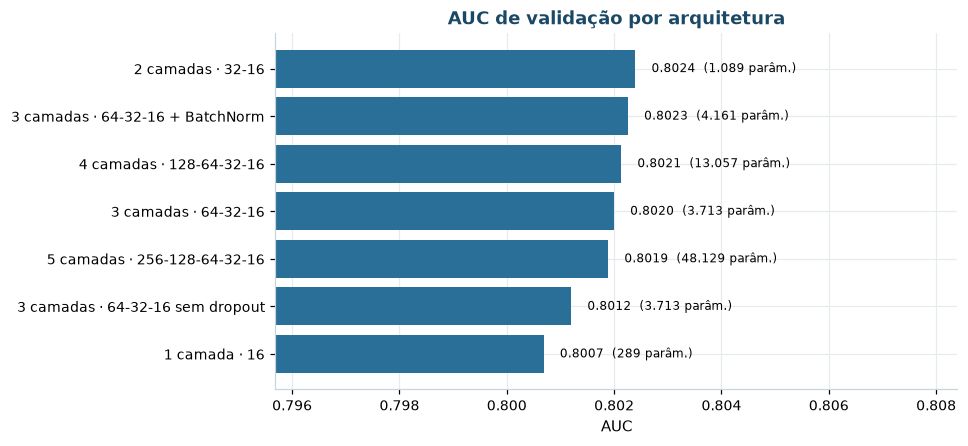

In [5]:
fig, eixo = plt.subplots(figsize=(8, 4.2))
ordem = tab_arq.sort_values("auc_val")
eixo.barh(ordem.index, ordem["auc_val"], color=config.AZUL_COBALTO)
for i, (v, n) in enumerate(zip(ordem["auc_val"], ordem["parametros"])):
    eixo.text(v + 0.0003, i, f"{v:.4f}  ({n:,} parâm.)".replace(",", "."), va="center", fontsize=8)
eixo.set(title="AUC de validação por arquitetura", xlabel="AUC",
         xlim=(ordem["auc_val"].min() - 0.005, ordem["auc_val"].max() + 0.006))
salvar_figura(fig, SECAO, "arquiteturas", ordem)
plt.show()

Da rede de 289 parâmetros à de 48 mil, a AUC de validação varia menos de 0,002 — um
**empate técnico**. Com 16 entradas tabulares, a informação disponível se esgota cedo e
mais neurônios não têm o que aprender. A coluna `distancia` (AUC de treino menos AUC de
validação) cresce um pouco com o tamanho da rede, mas fica abaixo de 0,005 em todas: com
41 mil pacientes e parada antecipada, nenhuma consegue sobreajustar de forma relevante.

A arquitetura adotada no modelo final (`src/model/treino.py`) é a de 3 camadas
64-32-16 com Dropout 0,2 e Adam — a mesma dos notebooks 02 e 03. Ela empata com as
melhores, tem poucos parâmetros e treina de forma estável.

## 3. O que as camadas ocultas aprendem: superfície de decisão em 2D

Uma rede com só **pressão sistólica e idade** como entradas permite desenhar a
probabilidade prevista em todo o plano. Compare com a reta do neurônio único do
notebook 01: aqui a fronteira pode se curvar.

AUC val com 2 entradas: 0.7863


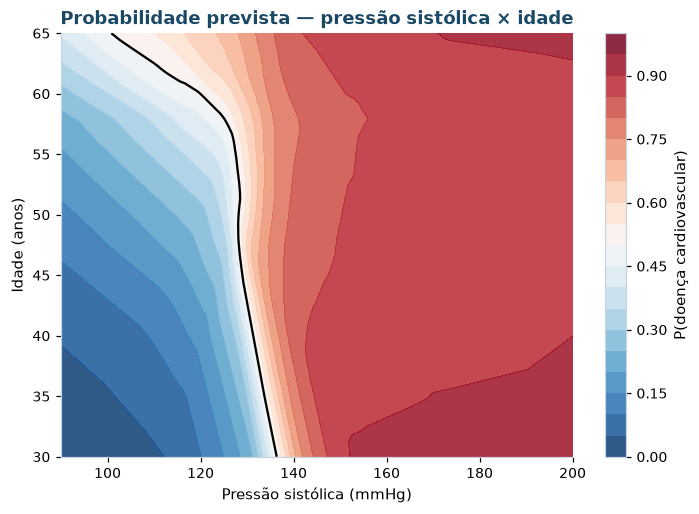

In [6]:
idx = [particao.nomes.index("ap_hi"), particao.nomes.index("idade_anos")]
X2, X2_val = particao.X_treino[:, idx], particao.X_val[:, idx]

rede2d = mlp_keras.construir_mlp(2, ocultas=(32, 16), dropout=0.1)
mlp_keras.treinar(rede2d, X2, particao.y_treino, X2_val, particao.y_val, epocas=60, paciencia=10)
print(f"AUC val com 2 entradas: {avaliacao.metricas(particao.y_val, mlp_keras.prever(rede2d, X2_val))['auc_roc']:.4f}")

# Grade na escala original, convertida para a escala padronizada da rede.
escala = particao.preprocessador.named_transformers_["continuas"]
cols = list(escala.feature_names_in_)
media = dict(zip(cols, escala.mean_))
desvio = dict(zip(cols, escala.scale_))
pa = np.linspace(90, 200, 220)
idade = np.linspace(30, 65, 220)
PA, ID = np.meshgrid(pa, idade)
grade = np.c_[(PA.ravel() - media["ap_hi"]) / desvio["ap_hi"],
              (ID.ravel() - media["idade_anos"]) / desvio["idade_anos"]].astype("float32")
Z = mlp_keras.prever(rede2d, grade).reshape(PA.shape)

fig, eixo = plt.subplots(figsize=(7.5, 5))
cf = eixo.contourf(PA, ID, Z, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.85)
eixo.contour(PA, ID, Z, levels=[0.5], colors="black", linewidths=1.5)
fig.colorbar(cf, ax=eixo, label="P(doença cardiovascular)")
eixo.grid(False)
eixo.set(title="Probabilidade prevista — pressão sistólica × idade",
         xlabel="Pressão sistólica (mmHg)", ylabel="Idade (anos)")
superficie = pd.DataFrame({"ap_hi": PA.ravel(), "idade_anos": ID.ravel(), "prob": Z.ravel()})
salvar_figura(fig, SECAO, "superficie-decisao-2d", superficie.iloc[::50])
plt.show()

Entre 35 e 55 anos, a fronteira (linha preta, p = 0,5) fica em **130–135 mmHg**, perto do
limiar clínico de hipertensão — a rede chegou a ele sozinha, só com os dados. Nas idades
mais altas ela se desloca bem para a esquerda (≈ 105 mmHg aos 64 anos): nessa faixa, até
pressões moderadas já indicam risco. E a probabilidade **satura** em ≈ 0,87–0,90 acima de
160 mmHg — o risco previsto não cresce indefinidamente, algo que um único neurônio (a
reta do notebook 01) não consegue representar.

## 4. Busca automática de hiperparâmetros (Keras Tuner)

Na seção 2, as arquiteturas foram escolhidas à mão. O **Keras Tuner** automatiza isso: o
espaço de busca está em `mlp_keras.modelo_para_busca` — de 1 a 4 camadas, largura inicial
de 16 a 256 neurônios, Dropout de 0 a 0,5, com ou sem BatchNorm e taxa de aprendizado entre
0,0001 e 0,01 (escala logarítmica).

O algoritmo **Hyperband** sorteia muitas combinações, treina cada uma por poucas épocas e
só dá mais épocas às melhores — como um torneio eliminatório. Assim explora dezenas de
redes no tempo de algumas poucas treinadas até o fim. O critério é a AUC de validação; o
teste continua guardado.

In [7]:
import functools
import tempfile

import keras
import keras_tuner as kt

buscador = kt.Hyperband(
    functools.partial(mlp_keras.modelo_para_busca, n_entradas=particao.n_entradas),
    objective=kt.Objective("val_auc", direction="max"),
    max_epochs=30,
    factor=3,
    seed=config.SEMENTE,
    directory=tempfile.mkdtemp(),  # checkpoints temporários, fora do repositório
    project_name="busca-mlp",
)
inicio = time.perf_counter()
buscador.search(
    particao.X_treino, particao.y_treino,
    validation_data=(particao.X_val, particao.y_val),
    batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping("val_auc", mode="max", patience=5)],
    verbose=0,
)
print(f"{len(buscador.oracle.trials)} redes treinadas em {time.perf_counter() - inicio:.0f}s")

linhas = []
for tentativa in buscador.oracle.trials.values():
    if tentativa.score is None:
        continue
    hp = tentativa.hyperparameters.values
    linhas.append({
        "tentativa": tentativa.trial_id,
        "camadas": hp["camadas"],
        "largura_inicial": hp["largura_inicial"],
        "dropout": hp["dropout"],
        "batch_norm": hp["batch_norm"],
        "taxa": hp["taxa"],
        "epocas": hp["tuner/epochs"],
        "auc_val": tentativa.score,
    })
busca = pd.DataFrame(linhas).set_index("tentativa").sort_values("auc_val", ascending=False)
salvar_tabela(busca, SECAO, "busca-hiperparametros")
busca.head(10)

/Users/joaopaulonascimento/Documents/CoracaoDadoDeepLearning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)


/Users/joaopaulonascimento/Documents/CoracaoDadoDeepLearning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)


/Users/joaopaulonascimento/Documents/CoracaoDadoDeepLearning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(store)


/Users/joaopaulonascimento/Documents/CoracaoDadoDeepLearning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(store)


/Users/joaopaulonascimento/Documents/CoracaoDadoDeepLearning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(store)


/Users/joaopaulonascimento/Documents/CoracaoDadoDeepLearning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)


90 redes treinadas em 275s


,camadas,largura_inicial,dropout,batch_norm,taxa,epocas,auc_val
tentativa,,,,,,,
0082,2,128,0.0,False,0.000356,30,0.802151
0080,2,128,0.0,False,0.000356,10,0.802004
0070,2,128,0.3,True,0.008553,10,0.801954
0050,3,128,0.1,False,0.001087,30,0.801867
0047,3,128,0.1,False,0.001087,10,0.801836
0073,2,128,0.1,False,0.002221,30,0.801812
0072,2,128,0.3,True,0.008553,30,0.801786
0083,3,256,0.4,True,0.002074,30,0.801712
0048,2,128,0.2,False,0.003299,10,0.801701


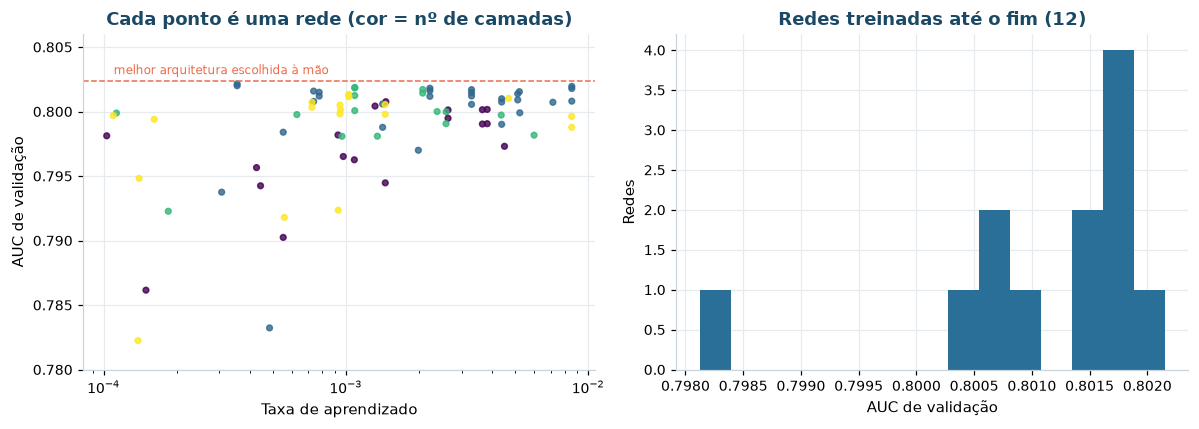

Melhor da busca: 0.8022  ·  melhor escolhida à mão: 0.8024


In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
completas = busca[busca["epocas"] == busca["epocas"].max()]
eixos[0].scatter(busca["taxa"], busca["auc_val"], s=14, c=busca["camadas"], cmap="viridis", alpha=0.8)
eixos[0].set(xscale="log", title="Cada ponto é uma rede (cor = nº de camadas)",
             xlabel="Taxa de aprendizado", ylabel="AUC de validação", ylim=(0.78, 0.806))
melhor_manual = tab_arq["auc_val"].max()
eixos[0].axhline(melhor_manual, color=config.CORAL, linestyle="--", linewidth=1)
eixos[0].text(1.1e-4, melhor_manual + 0.0005, "melhor arquitetura escolhida à mão", fontsize=8, color=config.CORAL)
eixos[1].hist(completas["auc_val"], bins=15, color=config.AZUL_COBALTO)
eixos[1].set(title=f"Redes treinadas até o fim ({len(completas)})", xlabel="AUC de validação", ylabel="Redes")
fig.tight_layout()
salvar_figura(fig, SECAO, "busca-hiperparametros", busca)
plt.show()
print(f"Melhor da busca: {busca['auc_val'].max():.4f}  ·  melhor escolhida à mão: {melhor_manual:.4f}")

A busca automática confirma, com dezenas de redes, o que a seção 2 mostrou com sete: a
melhor combinação encontrada fica no mesmo patamar (≈ 0,802–0,803) da melhor arquitetura
escolhida à mão. As taxas de aprendizado muito baixas ficam para trás porque não
convergem nas poucas épocas das rodadas iniciais; fora isso, profundidade, largura e
BatchNorm quase não importam. O Keras Tuner é valioso quando o espaço de busca é grande e
o resultado sensível a ele — aqui, sua principal contribuição é dar **evidência** de que
não há uma configuração muito melhor escondida.

## 5. Agenda da taxa de aprendizado

A taxa de aprendizado não precisa ser fixa. Duas estratégias comuns:

* **Redução no platô** (`ReduceLROnPlateau`) — quando a AUC de validação para de subir por
  algumas épocas, a taxa cai pela metade: passos grandes no início, ajuste fino no fim.
* **Decaimento cosseno** (`CosineDecay`) — a taxa desce suavemente de acordo com uma curva
  cosseno ao longo de um número fixo de passos.

In [9]:
passos_por_epoca = int(np.ceil(len(particao.y_treino) / 256))
agendas = {
    "Taxa fixa (0,001)": dict(taxa=1e-3, callbacks=[]),
    "Redução no platô": dict(
        taxa=1e-3,
        callbacks=[keras.callbacks.ReduceLROnPlateau("val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-5)],
    ),
    "Decaimento cosseno": dict(
        taxa=keras.optimizers.schedules.CosineDecay(3e-3, decay_steps=60 * passos_por_epoca, alpha=0.01),
        callbacks=[],
    ),
}

curvas_taxa, linhas = {}, []
for nome, kw in agendas.items():
    modelo = mlp_keras.construir_mlp(particao.n_entradas, taxa=kw["taxa"])
    registro = keras.callbacks.LambdaCallback()
    taxas = []
    registro.on_epoch_end = lambda epoca, logs, m=modelo, t=taxas: t.append(
        float(keras.ops.convert_to_numpy(m.optimizer.learning_rate))
    )
    hist = mlp_keras.treinar(
        modelo, particao.X_treino, particao.y_treino, particao.X_val, particao.y_val,
        epocas=60, paciencia=15, callbacks=[*kw["callbacks"], registro],
    )
    curvas_taxa[nome] = pd.DataFrame({"auc_val": hist.history["val_auc"], "taxa": taxas})
    linhas.append({
        "agenda": nome,
        "auc_val": avaliacao.metricas(particao.y_val, mlp_keras.prever(modelo, particao.X_val))["auc_roc"],
        "epocas": len(hist.history["loss"]),
    })
agendas_tab = pd.DataFrame(linhas).set_index("agenda")
agendas_tab

,auc_val,epocas
agenda,,
"Taxa fixa (0,001)",0.802358,42
Redução no platô,0.801766,40
Decaimento cosseno,0.802027,26


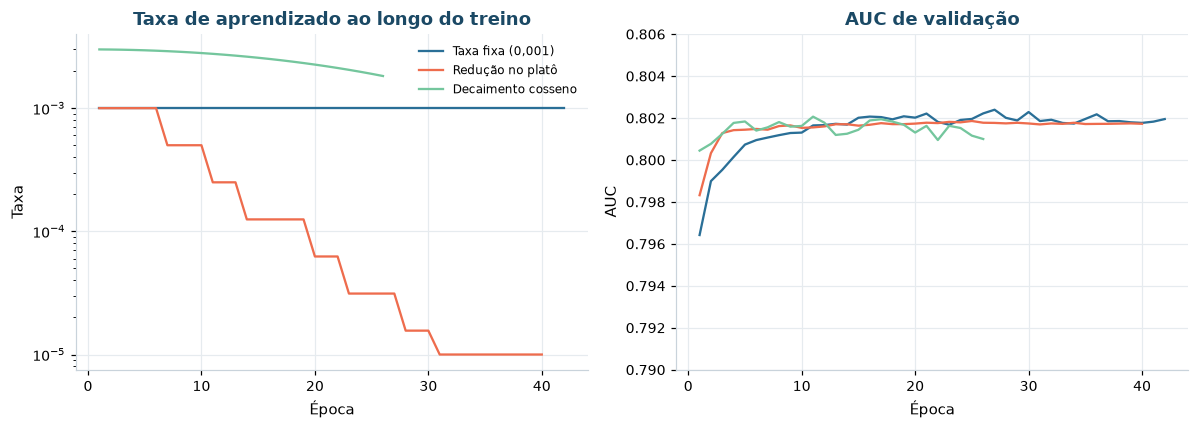

In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
for (nome, curva), cor in zip(curvas_taxa.items(), config.PALETA):
    eixos[0].plot(curva.index + 1, curva["taxa"], label=nome, color=cor)
    eixos[1].plot(curva.index + 1, curva["auc_val"], label=nome, color=cor)
eixos[0].set(title="Taxa de aprendizado ao longo do treino", xlabel="Época", ylabel="Taxa", yscale="log")
eixos[1].set(title="AUC de validação", xlabel="Época", ylabel="AUC", ylim=(0.79, 0.806))
eixos[0].legend(fontsize=8)
fig.tight_layout()
dados_agendas = pd.concat({k: v for k, v in curvas_taxa.items()}, names=["agenda", "epoca"])
salvar_figura(fig, SECAO, "agendas-taxa", dados_agendas)
salvar_tabela(agendas_tab, SECAO, "agendas-taxa-resumo")
plt.show()

As três agendas terminam no mesmo patamar de AUC (≈ 0,802). A diferença está na
**trajetória**:

* **Redução no platô** corta a taxa várias vezes até o mínimo (0,00001), e a curva de
  validação fica praticamente parada nas épocas finais: os passos ficam pequenos perto do
  ótimo, como esperado.
* **Decaimento cosseno** foi planejado para 60 épocas, mas a parada antecipada o
  interrompeu bem antes, quando a taxa ainda estava alta. Por isso ele não chegou à fase de
  ajuste fino. É uma interação comum: uma agenda com duração fixa e a parada antecipada
  competem pelo controle do treino, e é preciso escolher uma das duas ou aumentar a paciência.

Em problemas maiores (como o CIFAR-10 dos exercícios), a agenda costuma render ganho real;
aqui, com um teto dado pelos dados, ela serve principalmente para estabilizar o treino.